In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
from qiskit.circuit.library import QFT
import numpy as np
from numpy import pi

In [2]:
# 1 Qubit QFT
# e^2pi i jk/N
U = [[1, 1], [1,-1]]


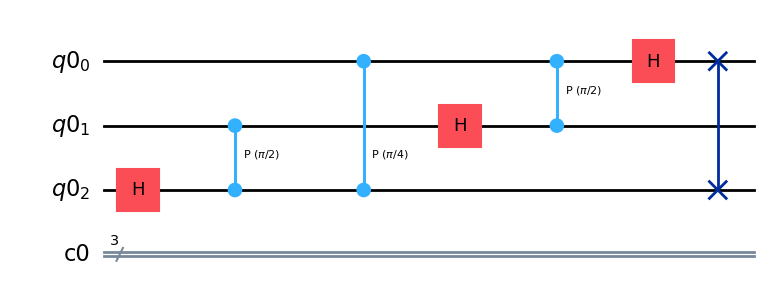

In [3]:
qr = QuantumRegister(3)
cr = ClassicalRegister(3)
qc = QuantumCircuit(qr, cr)

qc.h(2)
qc.cp(pi/2, 1, 2)
qc.cp(pi/4, 0, 2)

qc.h(1)
qc.cp(pi/2,0,1)
qc.h(0)

qc.swap(0, 2)
qc.draw("mpl")

In [4]:
bin(5)

'0b101'

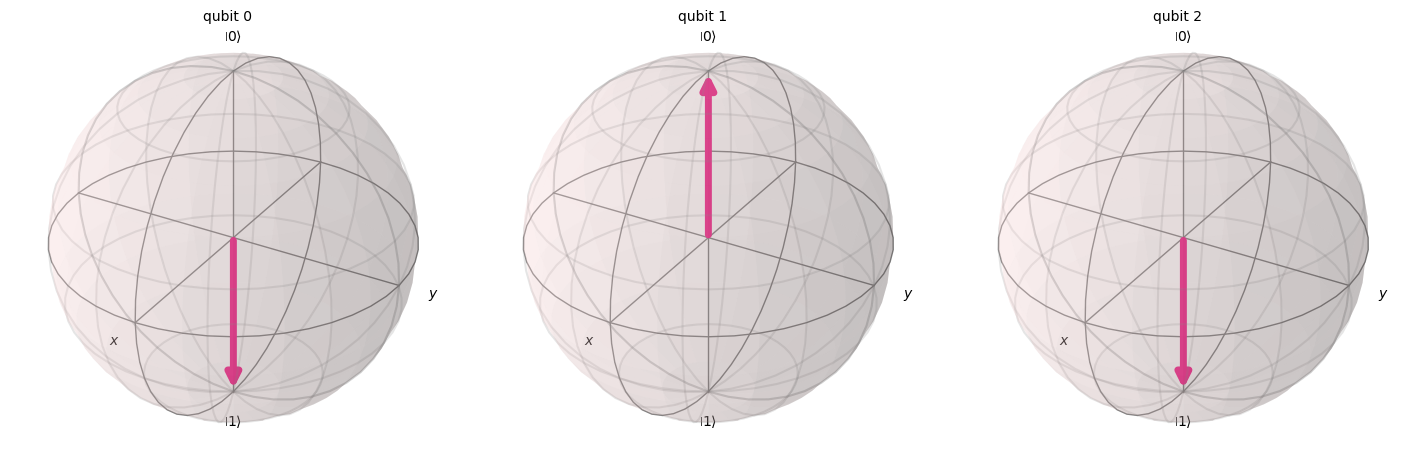

In [5]:
qc1 = QuantumCircuit(3)
qc1.x(0)
qc1.x(2)


statevector = Statevector(qc1)
plot_bloch_multivector(statevector)

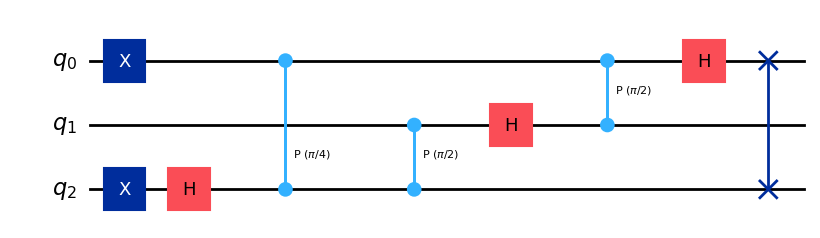

In [6]:
#add QFT
qc1.h(2)
qc1.cp(pi/4,0,2)
qc1.cp(pi/2,1,2)

qc1.h(1)
qc1.cp(pi/2,0,1)
qc1.h(0)

qc1.swap(0,2)
qc1.draw("mpl")

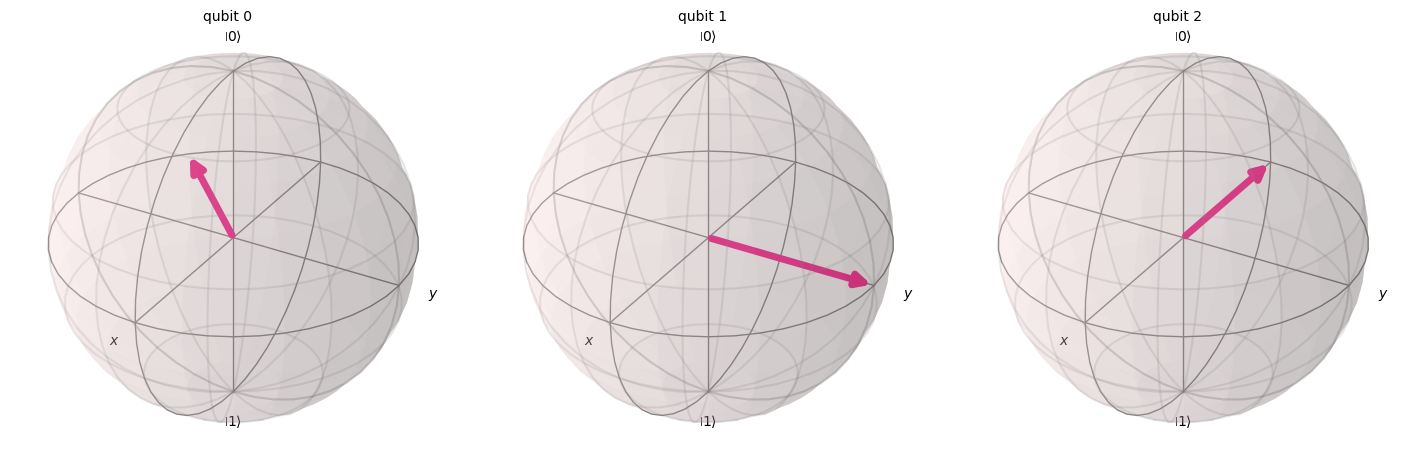

In [7]:
statevector = Statevector(qc1)
plot_bloch_multivector(statevector)

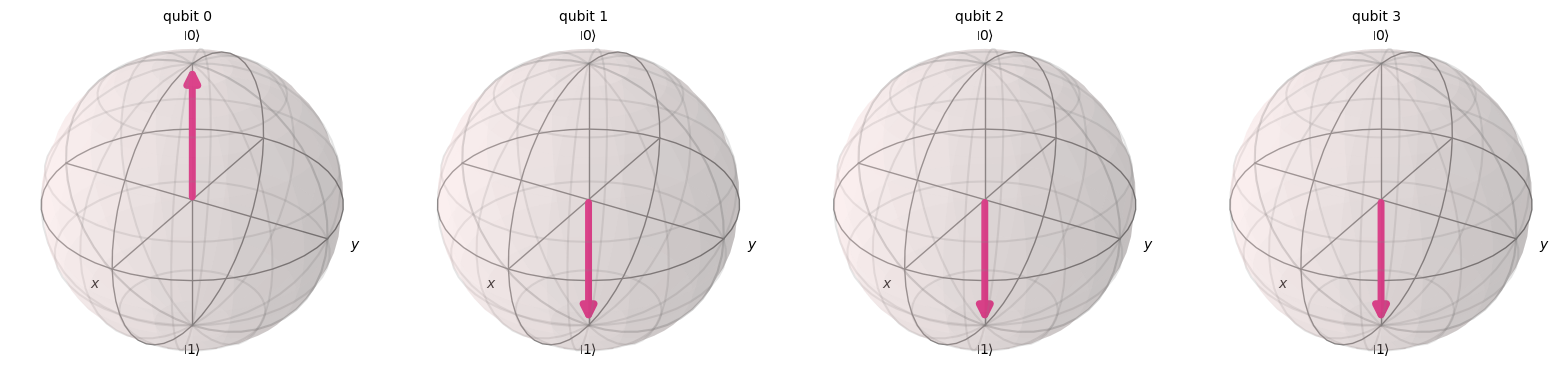

In [8]:
#QFT of 4 qubits
qc2 = QuantumCircuit(4)

qc2.x(3)
qc2.x(2)
qc2.x(1)

statevector = Statevector(qc2)
plot_bloch_multivector(statevector)

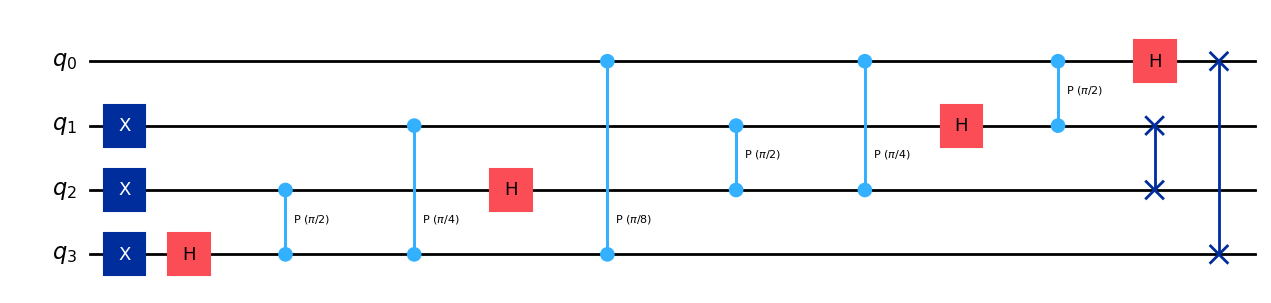

In [9]:
qc2.h(3)
qc2.cp(pi/2,2,3)
qc2.cp(pi/4,1,3)
qc2.cp(pi/8,0,3)

qc2.h(2)
qc2.cp(pi/2,1,2)
qc2.cp(pi/4,0,2)

qc2.h(1)
qc2.cp(pi/2,0,1)
qc2.h(0)
qc2.swap(0,3)
qc2.swap(1,2)

qc2.draw("mpl")

In [10]:
bin(14)

'0b1110'

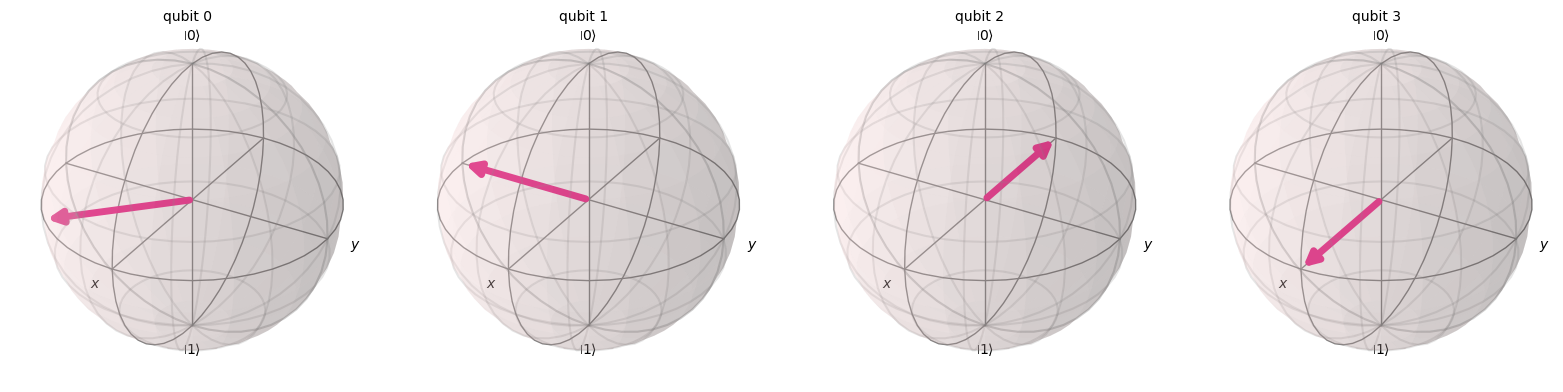

In [11]:
statevector = Statevector(qc2)
plot_bloch_multivector(statevector)

End of QFT course:
Left most qubit flips w every increment, next w 2 and third w 4 increments
goes from computational basis to state in fourier basis

rotations are different in fourier basis. e.g. encoding 5 on 4 qubits rotate leftmost qubit 5/2^n = 5/16 full turns (x2pi radians), double for other qubits.

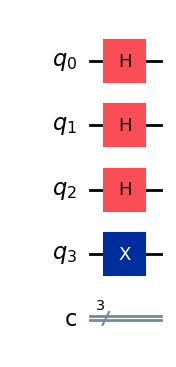

In [12]:
#QPE estimates theta in unitary operation U
#Example: T-Gate QPE

qpe = QuantumCircuit(4,3)
qpe.x(3)
qpe.draw("mpl")

for qubit in range(3):
    qpe.h(qubit)
qpe.draw("mpl")

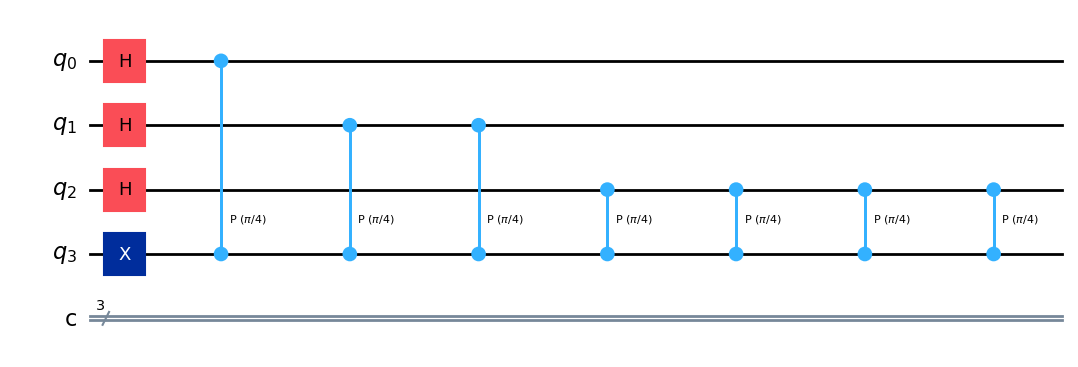

In [13]:
repetitions = 1
for counting_qubit in range(3):
    for i in range(repetitions):
        qpe.cp(pi / 4, counting_qubit, 3)  # This is C-Unitary
    repetitions *= 2
qpe.draw(output="mpl")

/tmp/ipykernel_310/2062629311.py:2: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qpe.append(QFT(3, inverse=True), [0, 1, 2])


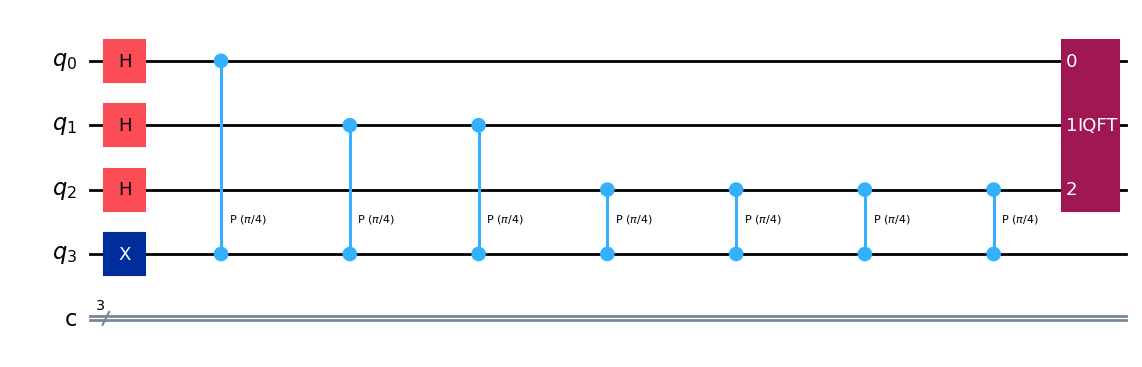

In [14]:
# Apply inverse QFT
qpe.append(QFT(3, inverse=True), [0, 1, 2])
qpe.draw(output="mpl")

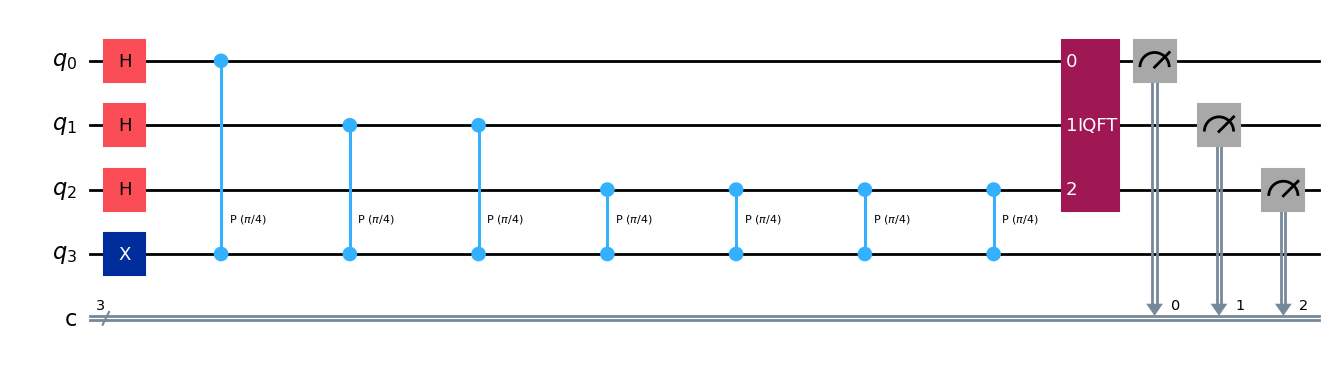

In [15]:
for n in range(3):
    qpe.measure(n, n)
qpe.draw(output="mpl")

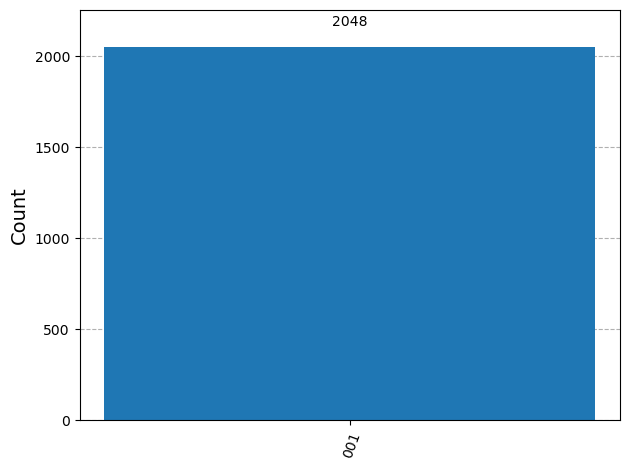

In [16]:
aer_sim = AerSimulator()
shots = 2048

pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
t_qpe = pm.run(qpe)

sampler = Sampler(mode=aer_sim)
job = sampler.run([t_qpe], shots=shots)
result = job.result()
answer = result[0].data.c.get_counts()

plot_histogram(answer)

/tmp/ipykernel_310/2415127855.py:18: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  q.append(QFT(3, inverse=True), [0, 1, 2])


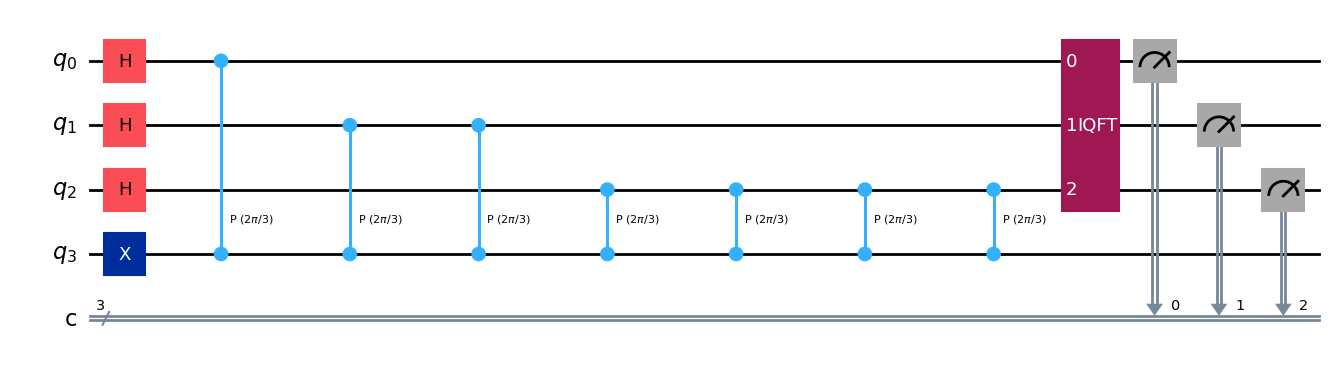

In [17]:
#Estimating theta=1/3 using 3 qubits for counting and a qubit for an eigenvector
lambd = (2*pi)/3

q = QuantumCircuit(4,3)
q.x(3)
for qubit in range(3):
    q.h(qubit)
q.draw("mpl")

angle = 2 * pi / 3
repetitions = 1
for counting_qubit in range(3):
    for i in range(repetitions):
        q.cp(angle, counting_qubit, 3)
    repetitions *= 2
    
# Do the inverse QFT:
q.append(QFT(3, inverse=True), [0, 1, 2])

for n in range(3):
    q.measure(n, n)

q.draw(output="mpl")

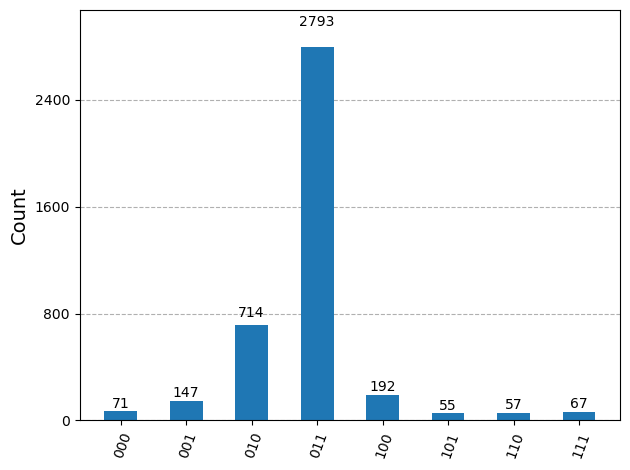

In [18]:
aer_sim = AerSimulator()
shots = 4096

pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
t_q = pm.run(q)

sampler = Sampler(mode=aer_sim)
job = sampler.run([t_q], shots=shots)
result = job.result()
answer = result[0].data.c.get_counts()

plot_histogram(answer)

In [19]:
#QPE Assignment
lamd1 = 0.5 #1
lamd2 = 1.5 # 3

from numpy import linalg as lg
U = [[1, -1/3], [-1/3,1]]

l = lg.eigvals(U)
print(l)
#l = 4/3, 2/3
#v = |1>,|0> 

eigenvalues, eigenvectors = np.linalg.eig(U)

print("Eigenvalues:", eigenvalues)
# The i-th eigenvalue
print("Eigenvector for the first eigenvalue:", eigenvectors[:, 0], eigenvectors[:, 1])


[1.33333333 0.66666667]
Eigenvalues: [1.33333333 0.66666667]
Eigenvector for the first eigenvalue: [ 0.70710678 -0.70710678] [0.70710678 0.70710678]


/tmp/ipykernel_310/325166492.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qpe3.append(QFT(3, inverse=True), [0, 1, 2])


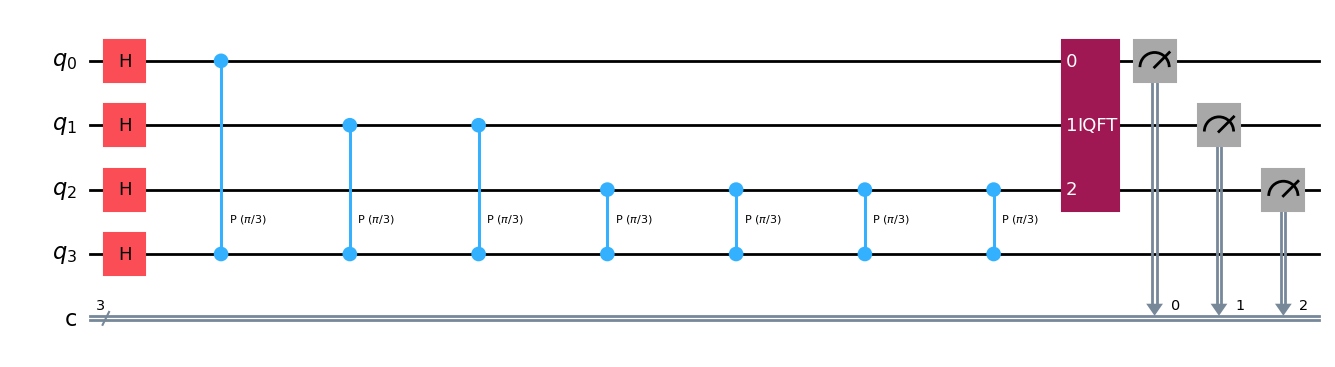

In [20]:
#set up system
qpe3 = QuantumCircuit(4,3)

#Focusing on eigenvalue = 2/3
#qpe3.x(3)
qpe3.h(3)

for qubit in range(3):
    qpe3.h(qubit)

angle = pi / 3
repetitions = 1
for counting_qubit in range(3):
    for i in range(repetitions):
        qpe3.cp(angle, counting_qubit, 3)
    repetitions *= 2
    
# Do the inverse QFT:
qpe3.append(QFT(3, inverse=True), [0, 1, 2])

for n in range(3):
    qpe3.measure(n, n)

qpe3.draw(output="mpl")

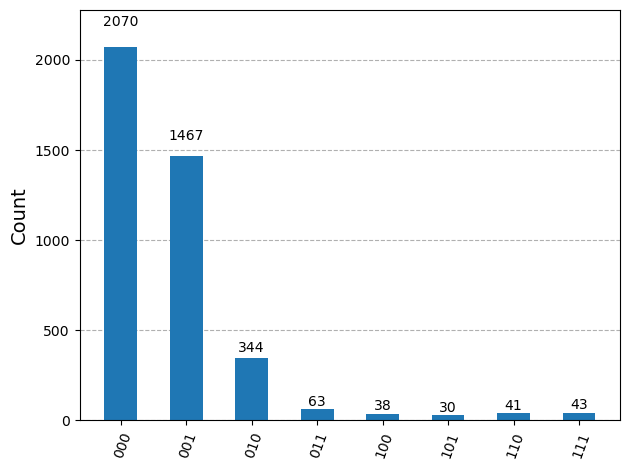

In [21]:
aer_sim = AerSimulator()
shots = 4096

pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
t_q = pm.run(qpe3)

sampler = Sampler(mode=aer_sim)
job = sampler.run([t_q], shots=shots)
result = job.result()
answer = result[0].data.c.get_counts()

plot_histogram(answer)


/tmp/ipykernel_310/4015731520.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qpe.append(QFT(2, inverse=True), [0, 1])


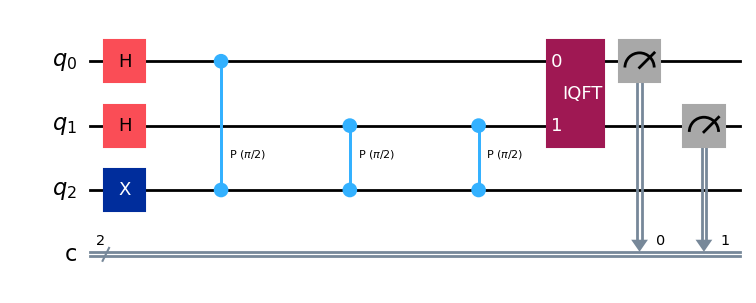

In [25]:
#QPE estimates theta in unitary operation U
#Example: S-gate

qpe = QuantumCircuit(3,2)
qpe.x(2)
qpe.draw("mpl")

for qubit in range(2):
    qpe.h(qubit)
qpe.draw("mpl")

repetitions = 1
for counting_qubit in range(2):
    for i in range(repetitions):
        qpe.cp(pi / 2, counting_qubit, 2)  # This is C-Unitary
    repetitions *= 2
qpe.draw(output="mpl")

qpe.append(QFT(2, inverse=True), [0, 1])

for n in range(2):
    qpe.measure(n,n)

qpe.draw("mpl")

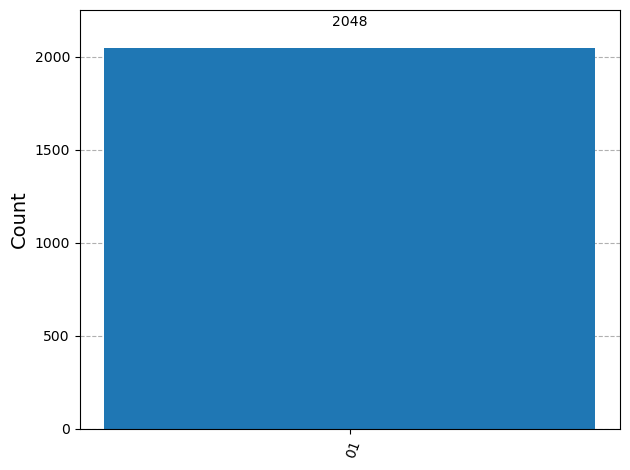

In [26]:
aer_sim = AerSimulator()
shots = 2048

pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
t_qpe = pm.run(qpe)

sampler = Sampler(mode=aer_sim)
job = sampler.run([t_qpe], shots=shots)
result = job.result()
answer = result[0].data.c.get_counts()

plot_histogram(answer)

This result gives us 01, which is the binary representation of 1. Divide this result by 2^n (n=counting qubits) to give us 1/4 which is the estimated theta that we expect.

/tmp/ipykernel_310/1877593440.py:14: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qp.append(QFT(3, inverse=True), [0,1,2])


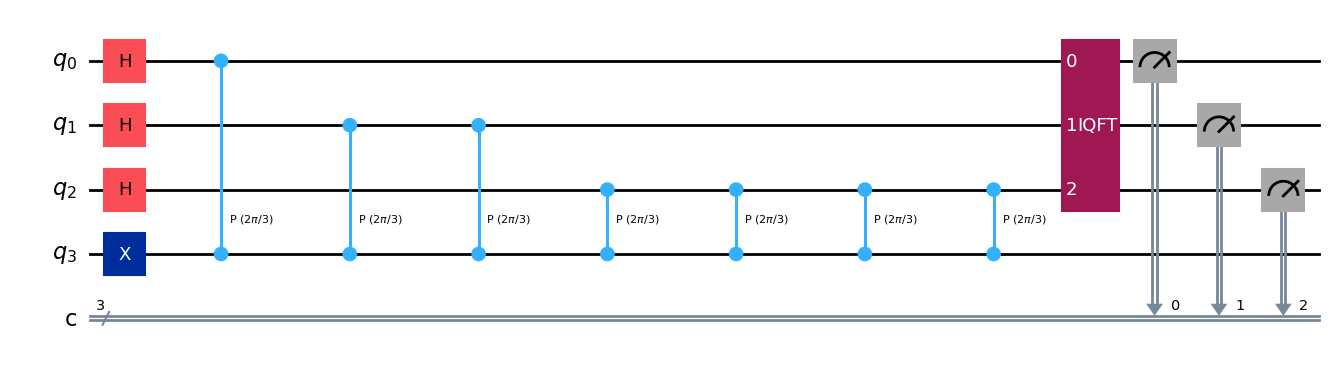

In [39]:
#Set-up: 3 counting registers and 1 register for eigenstate

qp = QuantumCircuit(4,3)
qp.x(3)
for qubit in range(3):
    qp.h(qubit)
    
repetitions = 1
for counting_qubit in range(3):
    for i in range(repetitions):
        qp.cp(2*pi / 3, counting_qubit, 3)  # This is C-Unitary
    repetitions *= 2

qp.append(QFT(3, inverse=True), [0,1,2])

for n in range(3):
    qp.measure(n,n)

qp.draw(output="mpl")


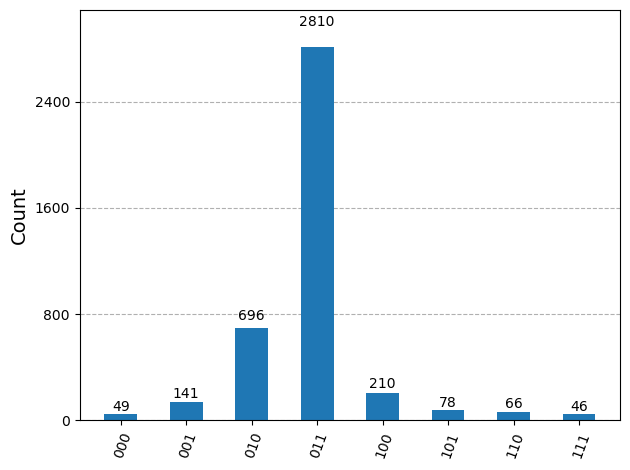

In [40]:
aer_sim = AerSimulator()
shots = 4096

pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
t_qp = pm.run(qp)

sampler = Sampler(mode=aer_sim)
job = sampler.run([t_qp], shots=shots)
result = job.result()
answer = result[0].data.c.get_counts()

plot_histogram(answer)
